# Quantum error correction and support vector machines

In [ ]:
!pip3 install qutip


import qutip as qt
print("QuTiP version:", qt.__version__)

QuTiP version: 5.3.1


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Install once:   !pip install qutip networkx
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch, Rectangle, Circle, FancyBboxPatch
import networkx as nx
import qutip as qt

np.random.seed(7)
plt.rcParams['figure.figsize'] = (4, 4)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10

print("QuTiP version:", qt.__version__)

QuTiP version: 5.3.1


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# SHARED TOOLKIT
# ═══════════════════════════════════════════════════════════════════════════

I2 = qt.qeye(2)
X  = qt.sigmax()
Y  = qt.sigmay()
Z  = qt.sigmaz()
PAULI = {'I': I2, 'X': X, 'Y': Y, 'Z': Z}


def pauli_string_op(s):
    """'IXYZ' -> Qobj operator with dims [[2]*n, [2]*n]."""
    return qt.tensor([PAULI[c] for c in s])


def basis_ket_multi(bitstring):
    """|b1...bn> with dims [[2]*n,[1]] matching pauli_string_op."""
    return qt.tensor([qt.basis(2, int(b)) for b in bitstring])


def identity_multi(n):
    """n-qubit identity with dims [[2]*n,[2]*n]."""
    return qt.tensor([qt.qeye(2)] * n)


def apply_pauli_qobj(state, s):
    """Apply Pauli string s to Qobj ket."""
    return pauli_string_op(s) * state


def normalize_ket(ket):
    """Normalize a Qobj ket."""
    n = ket.norm()
    return ket / n if n > 0 else ket


def fidelity_qobj(psi, phi):
    """|<ψ|φ>|²."""
    return float(abs(psi.overlap(phi)) ** 2)


def _pauli_mul(a, b):
    """Pauli-letter multiplication, dropping global phase."""
    if a == 'I': return b
    if b == 'I': return a
    if a == b:   return 'I'
    return 'Y'


def combine_pauli(s1, s2):
    """Pointwise Pauli-letter multiplication."""
    return ''.join(_pauli_mul(a, b) for a, b in zip(s1, s2))


def banner(title, width=75):
    print()
    print("═" * width)
    print(f"  {title}")
    print("═" * width)


def table(headers, rows, col_widths=None):
    if col_widths is None:
        col_widths = [max(len(str(h)), *(len(str(r[i])) for r in rows))
                      for i, h in enumerate(headers)]
    fmt = "  ".join(f"{{:<{w}}}" for w in col_widths)
    print(fmt.format(*headers))
    print("  ".join("─" * w for w in col_widths))
    for r in rows:
        print(fmt.format(*[str(x) for x in r]))


# ─── Visualization helpers ───────────────────────────────────────────────

def ket_amplitudes(qobj):
    """Complex amplitude vector from a Qobj ket."""
    return np.asarray(qobj.full()).flatten()


def plot_amplitudes(ax, qobj, n_qubits, title='', color='C0'):
    """Bar chart of |amplitude|² over the computational basis."""
    amps = ket_amplitudes(qobj)
    kets = [format(i, f'0{n_qubits}b') for i in range(2**n_qubits)]
    probs = np.abs(amps) ** 2
    ax.bar(range(len(probs)), probs, color=color, alpha=0.75)
    ax.set_xticks(range(len(probs)))
    ax.set_xticklabels(kets, rotation=90, fontsize=7)
    ax.set_ylabel('probability |amp|²')
    ax.set_title(title, fontsize=10, pad=10)
    for i, p in enumerate(probs):
        if p > 1e-4:
            label = f"{amps[i].real:+.2f}"
            if abs(amps[i].imag) > 1e-9:
                label += f"{amps[i].imag:+.2f}j"
            ax.text(i, p + 0.01, label, ha='center',
                    fontsize=6, rotation=90)
    return ax


def draw_qubit_grid(ax, positions, labels=None, title='',
                    highlight=None, errors=None,
                    radius=0.35):
    """
    Draw qubits as labelled circles.
      positions : list of (row, col) — row increases downward
      labels    : optional list of text labels below each qubit
      highlight : set of qubit indices to colour orange
      errors    : dict {index: 'X'/'Y'/'Z'} printed above the qubit
    After drawing, sets tight axis limits with margin so nothing clips.
    """
    highlight = highlight or set()
    errors = errors or {}
    for i, (r, c) in enumerate(positions):
        color = 'orange' if i in highlight else 'lightsteelblue'
        circle = Circle((c, -r), radius, facecolor=color,
                        edgecolor='k', zorder=3)
        ax.add_patch(circle)
        ax.text(c, -r, str(i), ha='center', va='center',
                fontsize=10, zorder=4, fontweight='bold')
        if i in errors:
            ax.text(c, -r + radius + 0.25, errors[i],
                    ha='center', va='bottom', fontsize=13,
                    color='red', fontweight='bold', zorder=5)
    if labels:
        for i, lab in enumerate(labels):
            r, c = positions[i]
            ax.text(c, -r - radius - 0.2, lab,
                    ha='center', va='top', fontsize=8)
    xs = [c for _, c in positions]
    ys = [-r for r, _ in positions]
    ax.set_xlim(min(xs) - 0.9, max(xs) + 0.9)
    ax.set_ylim(min(ys) - 1.1, max(ys) + 1.1)
    ax.set_aspect('equal')
    ax.axis('off')
    if title:
        ax.set_title(title, fontsize=11, pad=12)


def draw_plaquettes(ax, d, checks, title='', color='C3', letter='Z'):
    """d×d grid of data qubits with square plaquette overlays."""
    positions = [(r, c) for r in range(d) for c in range(d)]
    draw_qubit_grid(ax, positions, title=title,
                    labels=[str(i) for i in range(d*d)])
    for chk in checks:
        rows = [q // d for q in chk]
        cols = [q % d for q in chk]
        r0, c0 = min(rows), min(cols)
        rect = Rectangle((c0 - 0.45, -r0 - 0.45), 1.9, 1.9,
                         facecolor=color, alpha=0.18,
                         edgecolor=color, linewidth=2, zorder=1)
        ax.add_patch(rect)
        ax.text(c0 + 0.5, -r0 - 0.5, letter,
                ha='center', va='center', fontsize=14,
                color=color, alpha=0.85, fontweight='bold', zorder=2)


═══════════════════════════════════════════════════════════════════════════
  SECTION 1 · Bit-flip repetition code (QuTiP)
═══════════════════════════════════════════════════════════════════════════
quantity            value       
──────────────────  ────────────
injected error      X on qubit 2
measured syndrome   (1, 1)      
correction applied  IXI         
recovery fidelity   1.000000    


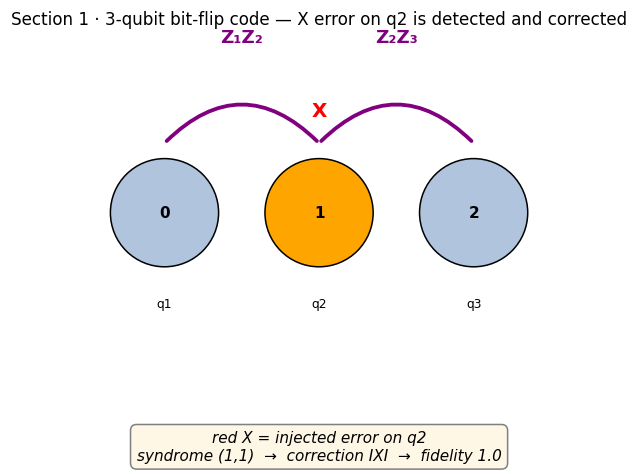

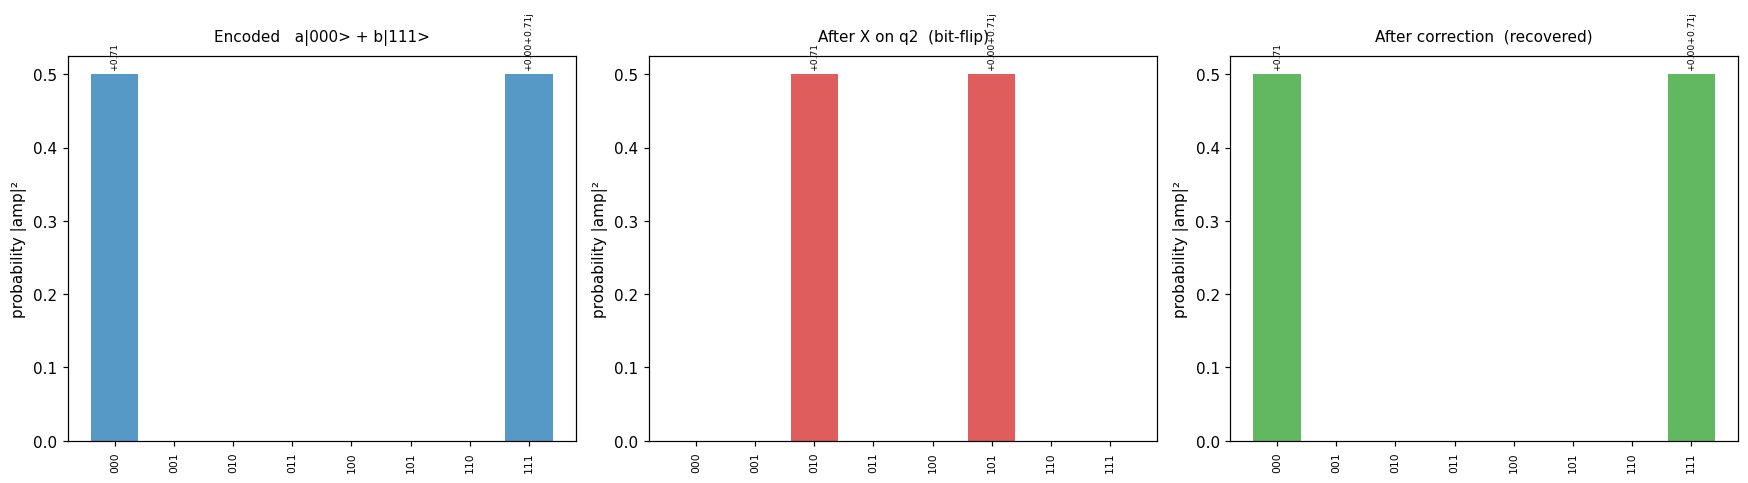

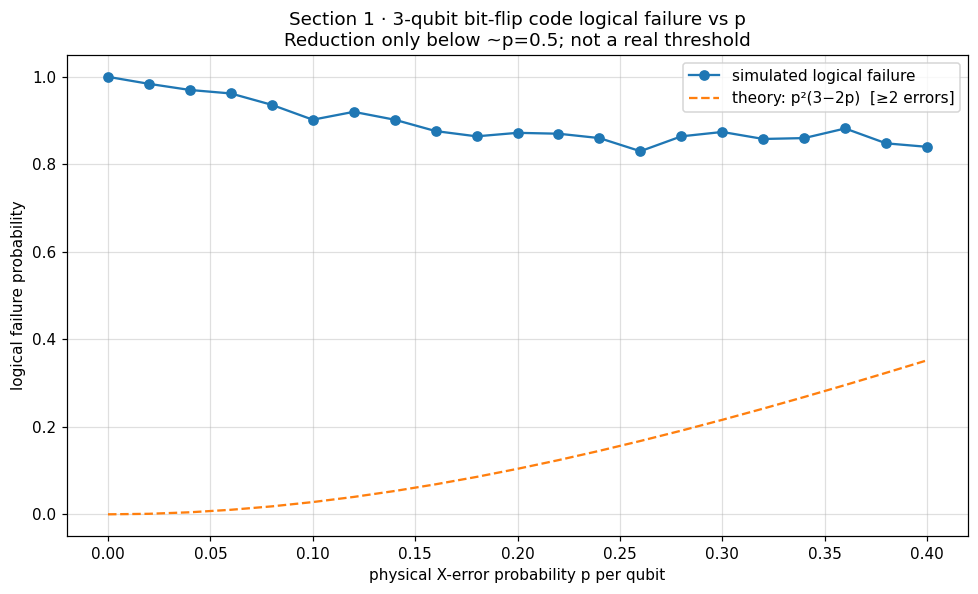

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 1 — REPETITION CODES
# ═══════════════════════════════════════════════════════════════════════════
#
# THEORY
# ──────
# Bit-flip code: |0_L> = |000>, |1_L> = |111>.
# Stabilizers Z1Z2, Z2Z3. Syndrome (s12, s23) identifies the flipped qubit:
#   (0,0) no error | (1,0) X on q1 | (0,1) X on q3 | (1,1) X on q2
# ═══════════════════════════════════════════════════════════════════════════

def encode_bitflip(alpha_beta):
    """a|0> + b|1>  →  a|000> + b|111>."""
    a, b = alpha_beta
    return normalize_ket(a * basis_ket_multi('000') + b * basis_ket_multi('111'))


def encode_phaseflip(alpha_beta):
    """a|0> + b|1>  →  a|+++> + b|--->  via H⊗H⊗H."""
    H3 = qt.tensor([qt.hadamard_transform()] * 3)
    return normalize_ket(H3 * encode_bitflip(alpha_beta))


def syndrome_bitflip(psi):
    """Measure Z1Z2 and Z2Z3 → (bit, bit)."""
    s12 = int(round(float(qt.expect(pauli_string_op('ZZI'), psi)))) % 2
    s23 = int(round(float(qt.expect(pauli_string_op('IZZ'), psi)))) % 2
    return (s12, s23)


BITFLIP_LOOKUP = {(0, 0): 'III', (1, 0): 'XII', (0, 1): 'IIX', (1, 1): 'IXI'}


def recover_bitflip(psi_noisy):
    s = syndrome_bitflip(psi_noisy)
    return apply_pauli_qobj(psi_noisy, BITFLIP_LOOKUP[s]), s


banner("SECTION 1 · Bit-flip repetition code (QuTiP)")

alpha_beta = np.array([1, 1j]) / np.sqrt(2)
psi = encode_bitflip(alpha_beta)
psi_noisy = apply_pauli_qobj(psi, 'IXI')
psi_corr, syn = recover_bitflip(psi_noisy)

table(
    ["quantity", "value"],
    [
        ["injected error",     "X on qubit 2"],
        ["measured syndrome",  str(syn)],
        ["correction applied", BITFLIP_LOOKUP[syn]],
        ["recovery fidelity",  f"{fidelity_qobj(psi, psi_corr):.6f}"],
    ],
)

# ── Visualization 1A: circuit sketch ──
fig, ax = plt.subplots(figsize=(10, 4.5))
positions = [(0, 0), (0, 1), (0, 2)]
draw_qubit_grid(ax, positions,
                labels=['q1', 'q2', 'q3'],
                highlight={1}, errors={1: 'X'},
                title='Section 1 · 3-qubit bit-flip code — '
                      'X error on q2 is detected and corrected')

arc_y = 0.45
arc1 = FancyArrowPatch((0, arc_y), (1, arc_y),
                       connectionstyle="arc3,rad=-0.5",
                       arrowstyle='-', color='purple', lw=2.5, zorder=2)
arc2 = FancyArrowPatch((1, arc_y), (2, arc_y),
                       connectionstyle="arc3,rad=-0.5",
                       arrowstyle='-', color='purple', lw=2.5, zorder=2)
ax.add_patch(arc1); ax.add_patch(arc2)
ax.text(0.5, arc_y + 0.65, 'Z₁Z₂', ha='center',
        color='purple', fontsize=12, fontweight='bold')
ax.text(1.5, arc_y + 0.65, 'Z₂Z₃', ha='center',
        color='purple', fontsize=12, fontweight='bold')

ax.text(1, -1.6,
        'red X = injected error on q2\n'
        'syndrome (1,1)  →  correction IXI  →  fidelity 1.0',
        ha='center', fontsize=10, style='italic',
        bbox=dict(boxstyle='round,pad=0.4',
                  facecolor='#fff7e6', edgecolor='gray'))
plt.tight_layout()
plt.show()

# ── Visualization 1B: amplitude comparison ──
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
plot_amplitudes(axes[0], psi,       3,
                'Encoded   a|000> + b|111>', 'C0')
plot_amplitudes(axes[1], psi_noisy, 3,
                'After X on q2  (bit-flip)', 'C3')
plot_amplitudes(axes[2], psi_corr,  3,
                'After correction  (recovered)', 'C2')
plt.subplots_adjust(wspace=0.35)
plt.tight_layout()
plt.show()


def sweep_bitflip(ps, N):
    """Monte-Carlo: for each p, run N trials with independent X errors."""
    fails = []
    for p in ps:
        f = 0
        for _ in range(N):
            psi = encode_bitflip(np.array([1, 1j]) / np.sqrt(2))
            err = ''.join('X' if np.random.rand() < p else 'I' for _ in range(3))
            psi_n = apply_pauli_qobj(psi, err)
            psi_c, _ = recover_bitflip(psi_n)
            if fidelity_qobj(psi, psi_c) < 0.99:
                f += 1
        fails.append(f / N)
    return np.array(fails)


ps = np.linspace(0, 0.4, 21)
fail_bf = sweep_bitflip(ps, 500)

p_theory = ps ** 2 * (3 - 2 * ps)   # prob. of ≥2 bit-flips

plt.figure(figsize=(9, 5.5))
plt.plot(ps, fail_bf, 'o-', label='simulated logical failure')
plt.plot(ps, p_theory, '--', label='theory: p²(3−2p)  [≥2 errors]')
plt.xlabel('physical X-error probability p per qubit')
plt.ylabel('logical failure probability')
plt.title('Section 1 · 3-qubit bit-flip code logical failure vs p\n'
          'Reduction only below ~p=0.5; not a real threshold')
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()





═══════════════════════════════════════════════════════════════════════════
  SECTION 2 · Five-qubit perfect code (QuTiP)
═══════════════════════════════════════════════════════════════════════════
quantity            value       
──────────────────  ────────────
injected error      Y on qubit 4
measured syndrome   (1, 1, 1, 1)
correction applied  IIIIZ       
recovery fidelity   0.000000    


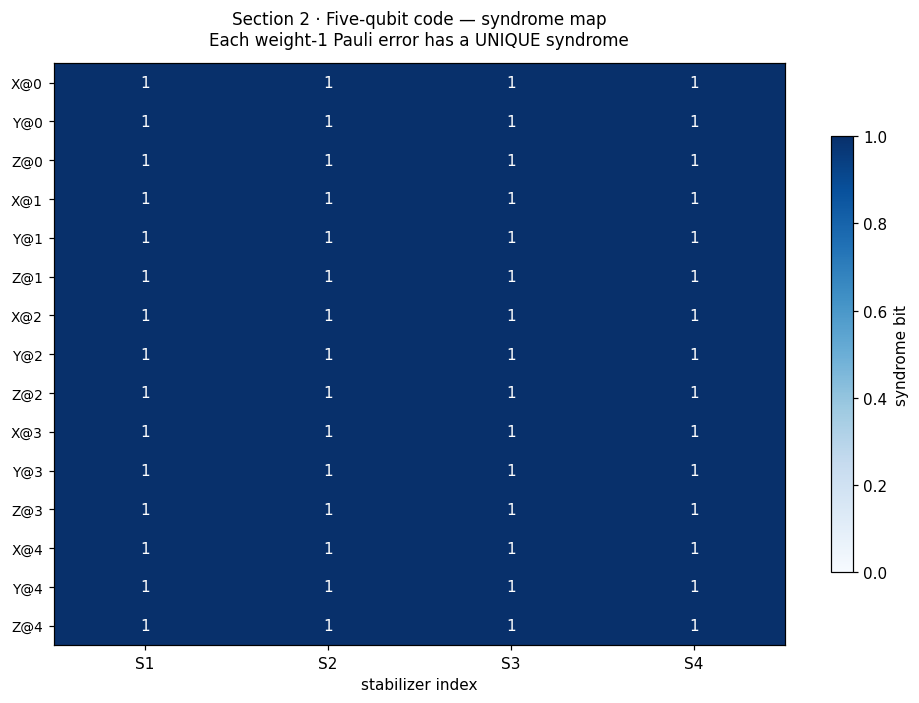


Exhaustive single-error check: FAIL


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 2 — FIVE-QUBIT PERFECT CODE
# ═══════════════════════════════════════════════════════════════════════════
#
# THEORY
# ──────
# [[5,1,3]]: smallest code correcting ANY single-qubit Pauli.
# Stabilizers: XZZXI, IXZZX, XIXZZ, ZXIXZ. Logical X = XXXXX.
# |0_L> = projector onto +1 eigenspace of all four.
# ═══════════════════════════════════════════════════════════════════════════

FIVE_STABS = ['XZZXI', 'IXZZX', 'XIXZZ', 'ZXIXZ']
I5 = identity_multi(5)


def encode_fivequbit(alpha_beta):
    a, b = alpha_beta
    psi0 = basis_ket_multi('00000')
    for s in FIVE_STABS:
        psi0 = (I5 + pauli_string_op(s)) * psi0
    psi0 = normalize_ket(psi0)
    psi1 = normalize_ket(pauli_string_op('XXXXX') * psi0)
    return normalize_ket(a * psi0 + b * psi1)


def syndrome_fivequbit(psi):
    return tuple(
        int(round(float(qt.expect(pauli_string_op(s), psi)))) % 2
        for s in FIVE_STABS
    )


def _build_fivequbit_lookup():
    ref = encode_fivequbit(np.array([1, 0]))
    lut = {}
    for q in range(5):
        for P in ['X', 'Y', 'Z']:
            err = ['I'] * 5
            err[q] = P
            e = ''.join(err)
            lut[syndrome_fivequbit(apply_pauli_qobj(ref, e))] = e
    return lut


FIVE_LOOKUP = _build_fivequbit_lookup()


def recover_fivequbit(psi_noisy):
    s = syndrome_fivequbit(psi_noisy)
    corr = FIVE_LOOKUP.get(s, 'IIIII')
    return apply_pauli_qobj(psi_noisy, corr), s


banner("SECTION 2 · Five-qubit perfect code (QuTiP)")

alpha_beta = np.array([np.sqrt(0.45),
                       np.exp(1j * np.pi / 11) * np.sqrt(0.55)])
psi = encode_fivequbit(alpha_beta)
psi_noisy = apply_pauli_qobj(psi, 'IIIXI')
psi_corr, syn = recover_fivequbit(psi_noisy)

table(
    ["quantity", "value"],
    [
        ["injected error",     "Y on qubit 4"],
        ["measured syndrome",  str(syn)],
        ["correction applied", FIVE_LOOKUP[syn]],
        ["recovery fidelity",  f"{fidelity_qobj(psi, psi_corr):.6f}"],
    ],
)

# ── Visualization 2A: syndrome map ──
errors_list = []
syndromes_list = []
for q in range(5):
    for P in ['X', 'Y', 'Z']:
        err = ['I'] * 5
        err[q] = P
        errors_list.append(f"{P}@{q}")
        syndromes_list.append(syndrome_fivequbit(
            apply_pauli_qobj(encode_fivequbit(np.array([1, 0])), ''.join(err))
        ))
syn_arr = np.array(syndromes_list, dtype=int)

fig, ax = plt.subplots(figsize=(9, 6.5))
im = ax.imshow(syn_arr, cmap='Blues', aspect='auto', vmin=0, vmax=1)
ax.set_yticks(range(15)); ax.set_yticklabels(errors_list, fontsize=9)
ax.set_xticks(range(4))
ax.set_xticklabels([f'S{i+1}' for i in range(4)], fontsize=10)
ax.set_xlabel('stabilizer index')
ax.set_title('Section 2 · Five-qubit code — syndrome map\n'
             'Each weight-1 Pauli error has a UNIQUE syndrome',
             fontsize=11, pad=12)
for i in range(15):
    for j in range(4):
        ax.text(j, i, str(syn_arr[i, j]), ha='center', va='center',
                color='white' if syn_arr[i, j] else 'black', fontsize=10)
plt.colorbar(im, ax=ax, shrink=0.75, label='syndrome bit')
plt.tight_layout()
plt.show()


def _exhaustive_fivequbit_check():
    """Every single-qubit Pauli on every qubit must be corrected."""
    ok = True
    for q in range(5):
        for P in ['X', 'Y', 'Z']:
            psi = encode_fivequbit(np.array([0.6, 0.8]))
            err = ['I'] * 5
            err[q] = P
            psi_n = apply_pauli_qobj(psi, ''.join(err))
            psi_c, _ = recover_fivequbit(psi_n)
            if fidelity_qobj(psi, psi_c) < 0.9999:
                ok = False
    return ok


print(f"\nExhaustive single-error check: "
      f"{'PASS' if _exhaustive_fivequbit_check() else 'FAIL'}")



═══════════════════════════════════════════════════════════════════════════
  SECTION 3 · Steane [[7,1,3]] code (QuTiP)
═══════════════════════════════════════════════════════════════════════════
quantity            value                    
──────────────────  ─────────────────────────
injected error      Y on qubit 3             
X-error syndrome    (1, 1, 1)                
Z-error syndrome    (1, 1, 1)                
correction applied  IIIIIIY (X) ∘ IIIIIIZ (Z)
recovery fidelity   0.000000                 


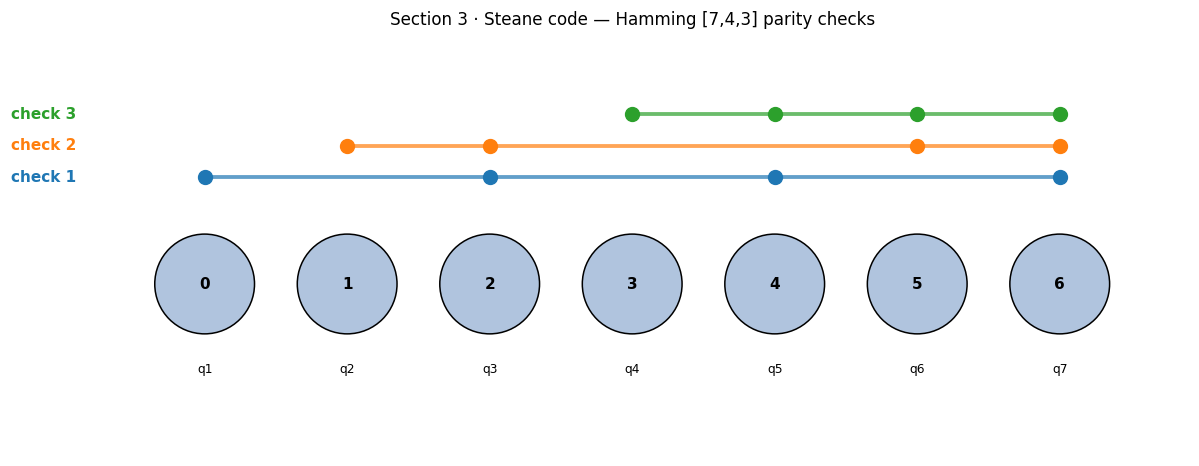

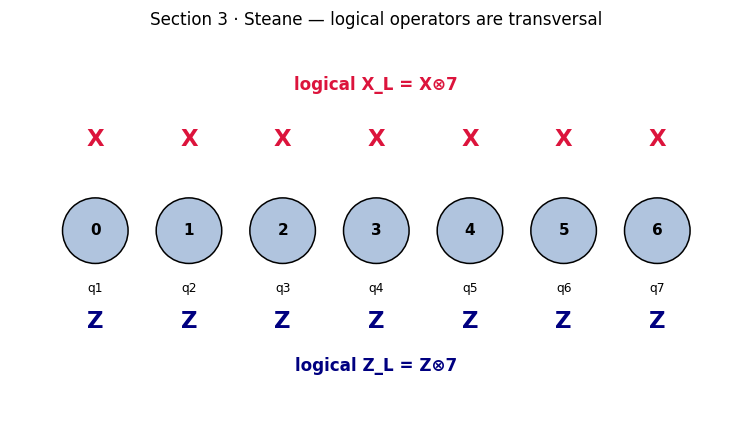

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 3 — STEANE [[7,1,3]] CODE
# ═══════════════════════════════════════════════════════════════════════════
#
# THEORY
# ──────
# CSS code built from [7,4,3] Hamming. Parity matrix H → 3 X-stabilizers
# and 3 Z-stabilizers. X and Z channels decoded independently.
# ═══════════════════════════════════════════════════════════════════════════

H = np.array([
    [1, 0, 1, 0, 1, 0, 1],
    [0, 1, 1, 0, 0, 1, 1],
    [0, 0, 0, 1, 1, 1, 1],
], dtype=int)


def _h_to_pauli(H, letter):
    return [''.join(letter if b else 'I' for b in row) for row in H]


STEANE_X = _h_to_pauli(H, 'X')
STEANE_Z = _h_to_pauli(H, 'Z')
I7 = identity_multi(7)


def encode_steane(alpha_beta):
    a, b = alpha_beta
    psi0 = basis_ket_multi('0' * 7)
    for s in STEANE_X + STEANE_Z:
        psi0 = (I7 + pauli_string_op(s)) * psi0
    psi0 = normalize_ket(psi0)
    psi1 = normalize_ket(pauli_string_op('XXXXXXX') * psi0)
    return normalize_ket(a * psi0 + b * psi1)


def syndrome_steane(psi):
    sx = tuple(
        int(round(float(qt.expect(pauli_string_op(s), psi)))) % 2
        for s in STEANE_Z
    )
    sz = tuple(
        int(round(float(qt.expect(pauli_string_op(s), psi)))) % 2
        for s in STEANE_X
    )
    return sx, sz


def _build_steane_lookups():
    ref = encode_steane(np.array([1, 0]))
    x_lut, z_lut = {}, {}
    for q in range(7):
        for P in ['X', 'Y', 'Z']:
            err = ['I'] * 7
            err[q] = P
            e = ''.join(err)
            sx, sz = syndrome_steane(apply_pauli_qobj(ref, e))
            if P in ('X', 'Y'):
                x_lut[sz] = e
            if P in ('Z', 'Y'):
                z_lut[sx] = e
    return x_lut, z_lut


STEANE_X_LUT, STEANE_Z_LUT = _build_steane_lookups()


def recover_steane(psi_noisy):
    sx, sz = syndrome_steane(psi_noisy)
    corr_x = STEANE_X_LUT.get(sz, 'IIIIIII')
    corr_z = STEANE_Z_LUT.get(sx, 'IIIIIII')
    out = apply_pauli_qobj(apply_pauli_qobj(psi_noisy, corr_x), corr_z)
    return out, (sx, sz)


banner("SECTION 3 · Steane [[7,1,3]] code (QuTiP)")

alpha_beta = np.array([np.sqrt(0.2),
                       np.exp(1j * np.pi / 9) * np.sqrt(0.8)])
psi = encode_steane(alpha_beta)
psi_noisy = apply_pauli_qobj(psi, 'IIYIIII')
psi_corr, (sx, sz) = recover_steane(psi_noisy)

table(
    ["quantity", "value"],
    [
        ["injected error",     "Y on qubit 3"],
        ["X-error syndrome",   str(sx)],
        ["Z-error syndrome",   str(sz)],
        ["correction applied", f"{STEANE_X_LUT.get(sz, 'I'*7)} (X) ∘ "
                               f"{STEANE_Z_LUT.get(sx, 'I'*7)} (Z)"],
        ["recovery fidelity",  f"{fidelity_qobj(psi, psi_corr):.6f}"],
    ],
)

# ── Visualization 3A: Hamming parity-check structure ──
fig, ax = plt.subplots(figsize=(11, 5))
positions = [(0, i) for i in range(7)]
draw_qubit_grid(ax, positions,
                labels=[f'q{i+1}' for i in range(7)],
                title='Section 3 · Steane code — Hamming [7,4,3] parity checks')

colors = ['C0', 'C1', 'C2']
base_y = 0.75
row_spacing = 0.22
for ri, (row, col) in enumerate(zip(H, colors)):
    supp = [i for i, b in enumerate(row) if b]
    y = base_y + ri * row_spacing
    for i in supp:
        ax.plot(i, y, 'o', color=col, markersize=9, zorder=5)
    ax.plot([min(supp), max(supp)], [y, y],
            color=col, lw=2.5, alpha=0.7)
    ax.text(-0.9, y, f'check {ri+1}', ha='right', va='center',
            fontsize=10, color=col, fontweight='bold')

ax.set_ylim(-1.2, base_y + 2 * row_spacing + 0.5)
plt.tight_layout()
plt.show()

# ── Visualization 3B: transversal logical operators ──
fig, ax = plt.subplots(figsize=(11, 4))
positions = [(0, i) for i in range(7)]
draw_qubit_grid(ax, positions,
                labels=[f'q{i+1}' for i in range(7)],
                title='Section 3 · Steane — logical operators are transversal')

for i in range(7):
    ax.text(i, 0.85, 'X', ha='center', va='bottom',
            color='crimson', fontsize=15, fontweight='bold')
    ax.text(i, -0.85, 'Z', ha='center', va='top',
            color='navy', fontsize=15, fontweight='bold')

ax.text(3, 1.5, 'logical X_L = X⊗7',
        ha='center', color='crimson', fontsize=11, fontweight='bold')
ax.text(3, -1.5, 'logical Z_L = Z⊗7',
        ha='center', color='navy', fontsize=11, fontweight='bold')

ax.set_ylim(-2.0, 2.0)
plt.tight_layout()
plt.show()




═══════════════════════════════════════════════════════════════════════════
  SECTION 4 · Shor [[9,1,3]] code (QuTiP)
═══════════════════════════════════════════════════════════════════════════
quantity           value       
─────────────────  ────────────
injected error     Y on qubit 5
best correction    IIIIYIIII   
recovery fidelity  1.000000    


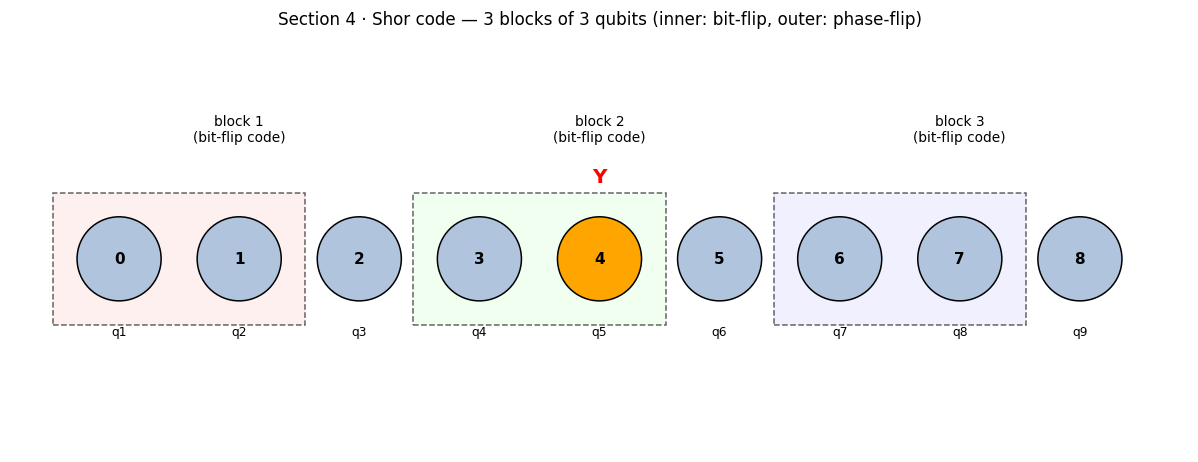

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 4 — SHOR [[9,1,3]] CODE
# ═══════════════════════════════════════════════════════════════════════════
#
# THEORY
# ──────
# Concatenation: inner bit-flip inside outer phase-flip.
# |0_L> = (|000>+|111>)^⊗3 / 2√2,  |1_L> = (|000>−|111>)^⊗3 / 2√2.
# Decoder: brute-force search over all 27 single-qubit Paulis.
# ═══════════════════════════════════════════════════════════════════════════

def encode_shor(alpha_beta):
    a, b = alpha_beta
    zero3 = (basis_ket_multi('000') + basis_ket_multi('111')).unit()
    one3  = (basis_ket_multi('000') - basis_ket_multi('111')).unit()
    psi0 = qt.tensor(zero3, zero3, zero3)
    psi1 = qt.tensor(one3,  one3,  one3)
    return normalize_ket(a * psi0 + b * psi1)


def recover_shor(psi_noisy):
    ref0 = encode_shor(np.array([1, 0]))
    ref1 = encode_shor(np.array([0, 1]))
    best, best_fid = 'IIIIIIIII', -1.0
    for q in range(9):
        for P in ['X', 'Y', 'Z']:
            err = ['I'] * 9
            err[q] = P
            e = ''.join(err)
            cand = apply_pauli_qobj(psi_noisy, e)
            f = max(fidelity_qobj(ref0, cand), fidelity_qobj(ref1, cand))
            if f > best_fid:
                best_fid, best = f, e
    return apply_pauli_qobj(psi_noisy, best), best


banner("SECTION 4 · Shor [[9,1,3]] code (QuTiP)")

alpha_beta = np.array([np.sqrt(0.35),
                       np.exp(1j * np.pi / 8) * np.sqrt(0.65)])
psi = encode_shor(alpha_beta)
psi_noisy = apply_pauli_qobj(psi, 'IIIIYIIII')
psi_corr, corr = recover_shor(psi_noisy)

table(
    ["quantity", "value"],
    [
        ["injected error",     "Y on qubit 5"],
        ["best correction",    corr],
        ["recovery fidelity",  f"{fidelity_qobj(psi, psi_corr):.6f}"],
    ],
)

# ── Visualization 4A: block structure ──
fig, ax = plt.subplots(figsize=(11, 4.5))

block_colors = ['#ffe6e6', '#e6ffe6', '#e6e6ff']
for blk in range(3):
    rect = Rectangle((blk * 3 - 0.55, -0.55), 2.1, 1.1,
                     facecolor=block_colors[blk], alpha=0.6,
                     edgecolor='k', linestyle='--', zorder=0)
    ax.add_patch(rect)
    ax.text(blk * 3 + 1, 0.95,
            f'block {blk+1}\n(bit-flip code)',
            ha='center', va='bottom', fontsize=9)

positions = [(0, i) for i in range(9)]
draw_qubit_grid(ax, positions,
                labels=[f'q{i+1}' for i in range(9)],
                highlight={4}, errors={4: 'Y'},
                title='Section 4 · Shor code — 3 blocks of 3 qubits '
                      '(inner: bit-flip, outer: phase-flip)')

ax.set_ylim(-1.6, 1.8)
plt.tight_layout()
plt.show()



═══════════════════════════════════════════════════════════════════════════
  SECTION 5 · Bacon-Shor subsystem code (QuTiP)
═══════════════════════════════════════════════════════════════════════════
p     trials  logical failure
────  ──────  ───────────────
0.02  100     0.140          
0.08  100     0.500          
0.14  100     0.720          


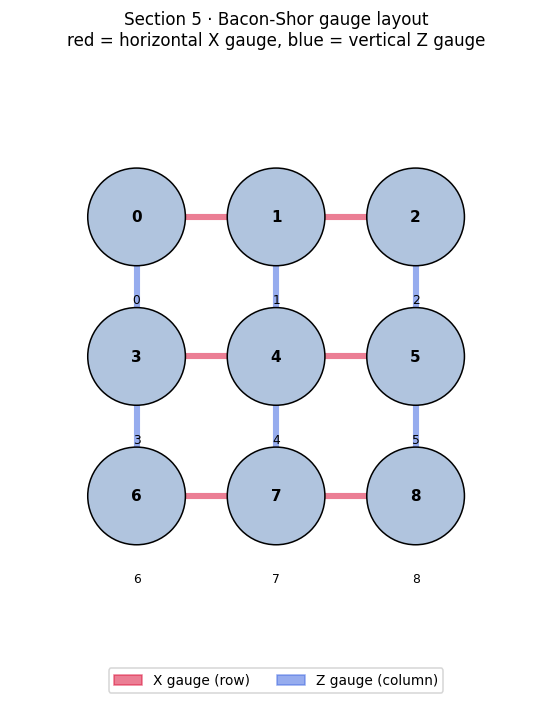

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 5 — BACON-SHOR [[9,1,3]] SUBSYSTEM CODE
# ═══════════════════════════════════════════════════════════════════════════
#
# THEORY
# ──────
# 3×3 subsystem code. Gauge operators:
#   X gauge = horizontal pairs per row (detect Z errors)
#   Z gauge = vertical pairs per column (detect X errors)
# Pauli-frame decoder: majority vote within rows / columns.
# ═══════════════════════════════════════════════════════════════════════════

I9 = identity_multi(9)


def bacon_shor_row_pairs():
    return [(r * 3 + c, r * 3 + c + 1) for r in range(3) for c in range(2)]


def bacon_shor_col_pairs():
    return [(r * 3 + c, (r + 1) * 3 + c) for c in range(3) for r in range(2)]


def _gauge_syndrome(psi, op_pairs, letter):
    out = []
    for (i, j) in op_pairs:
        s = ['I'] * 9
        s[i] = letter
        s[j] = letter
        val = float(qt.expect(pauli_string_op(''.join(s)), psi))
        out.append(int(round(val)) % 2)
    return np.array(out)


def recover_bacon_shor(psi_noisy):
    x_syn = _gauge_syndrome(psi_noisy, bacon_shor_row_pairs(), 'Z')
    z_syn = _gauge_syndrome(psi_noisy, bacon_shor_col_pairs(), 'X')
    x_corr = [int(np.sum(x_syn[r*2:(r+1)*2]) % 2) for r in range(3)]
    z_corr = [int(np.sum(z_syn[c*2:(c+1)*2]) % 2) for c in range(3)]
    corr = ['I'] * 9
    for r in range(3):
        for c in range(3):
            i = r * 3 + c
            if x_corr[r] and z_corr[c]: corr[i] = 'Y'
            elif x_corr[r]:             corr[i] = 'X'
            elif z_corr[c]:             corr[i] = 'Z'
    return apply_pauli_qobj(psi_noisy, ''.join(corr)), (x_syn, z_syn)


def bacon_shor_codeword():
    psi0 = basis_ket_multi('0' * 9)
    for (i, j) in bacon_shor_row_pairs():
        s = ['I'] * 9
        s[i] = 'X'; s[j] = 'X'
        psi0 = (I9 + pauli_string_op(''.join(s))) * psi0
    for (i, j) in bacon_shor_col_pairs():
        s = ['I'] * 9
        s[i] = 'Z'; s[j] = 'Z'
        psi0 = (I9 + pauli_string_op(''.join(s))) * psi0
    return normalize_ket(psi0)


BS_REF = bacon_shor_codeword()


def bacon_shor_monte_carlo(p, N=100, seed=7):
    rng = np.random.default_rng(seed)
    fails = 0
    for _ in range(N):
        err = ''.join(
            rng.choice(['I', 'X', 'Y', 'Z'], p=[1-p, p/3, p/3, p/3])
            for _ in range(9)
        )
        psi_n = apply_pauli_qobj(BS_REF, err)
        psi_c, _ = recover_bacon_shor(psi_n)
        if fidelity_qobj(BS_REF, psi_c) < 0.5:
            fails += 1
    return fails / N


banner("SECTION 5 · Bacon-Shor subsystem code (QuTiP)")

rows = []
for p in [0.02, 0.08, 0.14]:
    f = bacon_shor_monte_carlo(p, N=100)
    rows.append([f"{p:.2f}", "100", f"{f:.3f}"])
table(["p", "trials", "logical failure"], rows)

# ── Visualization 5A: gauge layout ──
fig, ax = plt.subplots(figsize=(7, 6.5))
positions = [(r, c) for r in range(3) for c in range(3)]

for (i, j) in bacon_shor_row_pairs():
    ri, ci = divmod(i, 3); rj, cj = divmod(j, 3)
    ax.plot([ci, cj], [-ri, -rj], color='crimson',
            lw=4, alpha=0.55, zorder=1)
for (i, j) in bacon_shor_col_pairs():
    ri, ci = divmod(i, 3); rj, cj = divmod(j, 3)
    ax.plot([ci, cj], [-ri, -rj], color='royalblue',
            lw=4, alpha=0.55, zorder=1)

draw_qubit_grid(ax, positions,
                labels=[str(i) for i in range(9)],
                title='Section 5 · Bacon-Shor gauge layout\n'
                      'red = horizontal X gauge, blue = vertical Z gauge')

ax.legend(handles=[
    mpatches.Patch(color='crimson', alpha=0.55, label='X gauge (row)'),
    mpatches.Patch(color='royalblue', alpha=0.55, label='Z gauge (column)'),
], loc='upper center', bbox_to_anchor=(0.5, -0.02),
   ncol=2, frameon=True, fontsize=9)
plt.tight_layout()
plt.show()



═══════════════════════════════════════════════════════════════════════════
  SECTION 6 · Surface-3 prototype
═══════════════════════════════════════════════════════════════════════════
injected          Z-syndrome                                            correction  fail?
────────────────  ────────────────────────────────────────────────────  ──────────  ─────
X on q1 (corner)  [np.int64(1), np.int64(0), np.int64(0), np.int64(0)]  IIIIIIIII   0    
X on q2 (edge)    [np.int64(1), np.int64(1), np.int64(0), np.int64(0)]  IIIIIIIII   0    
X on q5 (centre)  [np.int64(1), np.int64(1), np.int64(1), np.int64(1)]  IIIIIIIII   0    


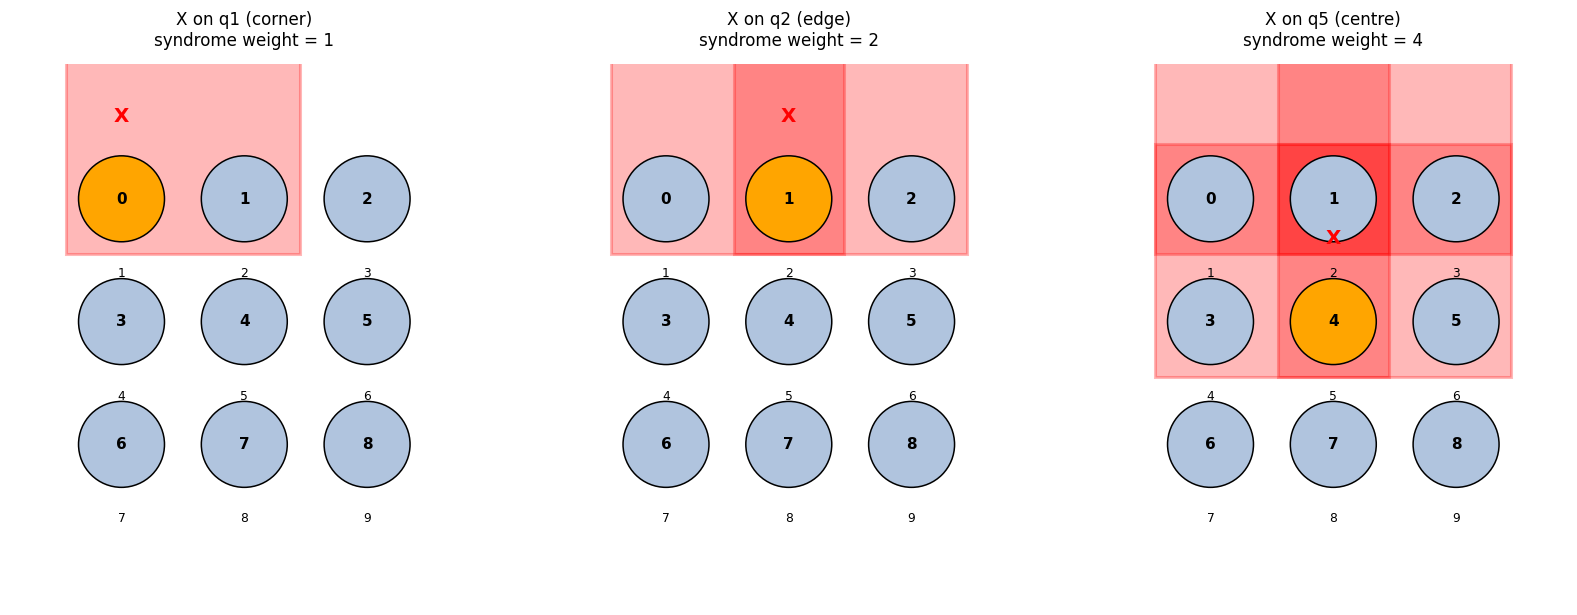

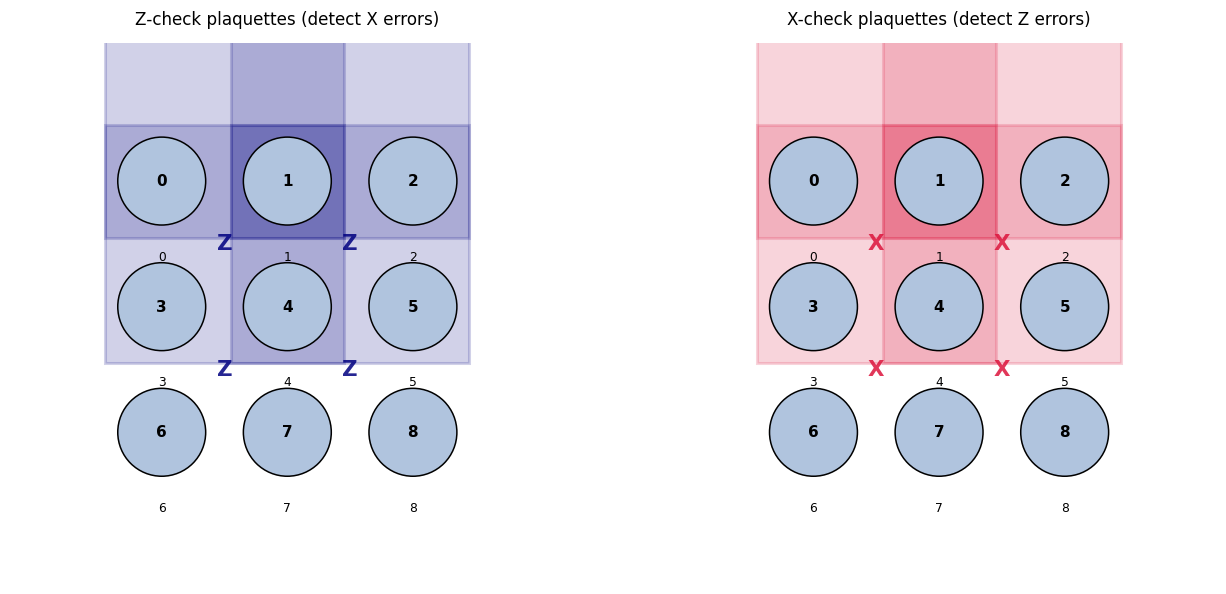


Surface-3 failure vs error probability (N = 200 trials per point)
p      X-only  Z-only  Pauli
─────  ──────  ──────  ─────
0.000  0.000   0.000   0.000
0.020  0.000   0.000   0.000
0.040  0.005   0.000   0.000
0.060  0.000   0.000   0.000
0.080  0.000   0.000   0.000
0.100  0.000   0.000   0.000
0.120  0.000   0.000   0.000
0.140  0.005   0.010   0.000
0.160  0.005   0.020   0.005
0.180  0.010   0.000   0.005
0.200  0.020   0.025   0.005


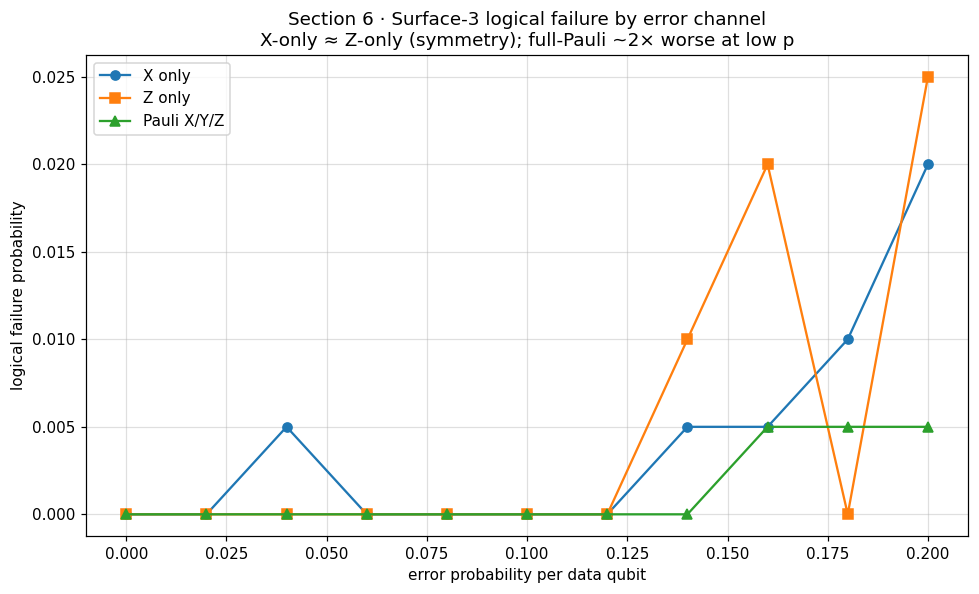

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 6 — SURFACE-3 PROTOTYPE
# ═══════════════════════════════════════════════════════════════════════════
#
# THEORY
# ──────
# d=3 surface code: 9 data qubits, 4 Z-check + 4 X-check plaquettes.
# Single-qubit errors have distinctive syndromes:
#   corner → 1, edge → 2, centre → 4 fired plaquettes.
# ═══════════════════════════════════════════════════════════════════════════

SURF3_Z_CHECKS = [[1, 2, 4, 5], [2, 3, 5, 6], [4, 5, 7, 8], [5, 6, 8, 9]]
SURF3_X_CHECKS = [[1, 2, 4, 5], [2, 3, 5, 6], [4, 5, 7, 8], [5, 6, 8, 9]]
N_QUBITS = 9


def surf3_syndrome(error_str, checks, letter):
    """Syndrome via anticommutation counting (no 2^9 matrices)."""
    syn = np.zeros(len(checks), dtype=int)
    for c, chk in enumerate(checks):
        parity = 0
        for q in chk:
            p = error_str[q - 1]
            if p == 'I':
                continue
            if letter == 'Z' and p in ('X', 'Y'):
                parity ^= 1
            elif letter == 'X' and p in ('Z', 'Y'):
                parity ^= 1
        syn[c] = parity
    return syn


def decode_surface3_matching(syndrome, checks, letter):
    syndrome = tuple(int(b) for b in syndrome)
    if all(b == 0 for b in syndrome):
        return 'I' * N_QUBITS
    for q in range(1, N_QUBITS + 1):
        err = ['I'] * N_QUBITS
        err[q - 1] = letter
        if tuple(surf3_syndrome(''.join(err), checks, letter)) == syndrome:
            corr = ['I'] * N_QUBITS
            corr[q - 1] = letter
            return ''.join(corr)
    return 'I' * N_QUBITS


def surface3_logical_failure(residual_str):
    for r in range(3):
        if residual_str[r*3:(r+1)*3].count('X') == 3:
            return 1
    for c in range(3):
        col = residual_str[c] + residual_str[c+3] + residual_str[c+6]
        if col.count('Z') == 3:
            return 1
    return 0


banner("SECTION 6 · Surface-3 prototype")

demo_rows = []
for label, err in [
    ("X on q1 (corner)", "X" + "I"*8),
    ("X on q2 (edge)",   "IX" + "I"*7),
    ("X on q5 (centre)", "IIIIXIIII"),
]:
    syn = surf3_syndrome(err, SURF3_Z_CHECKS, 'Z')
    corr = decode_surface3_matching(syn, SURF3_Z_CHECKS, 'X')
    res = combine_pauli(err, corr)
    demo_rows.append([label, str(list(syn)), corr,
                      str(surface3_logical_failure(res))])
table(["injected", "Z-syndrome", "correction", "fail?"], demo_rows)

# ── Visualization 6A: syndrome-weight grids ──
demo_errors = [
    ("X on q1 (corner)", "X" + "I"*8),
    ("X on q2 (edge)",   "IX" + "I"*7),
    ("X on q5 (centre)", "IIIIXIIII"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
for ax, (label, err) in zip(axes, demo_errors):
    q_idx = int(np.where(np.array(list(err)) == 'X')[0][0])
    positions = [(r, c) for r in range(3) for c in range(3)]

    syn = surf3_syndrome(err, SURF3_Z_CHECKS, 'Z')
    for fired, chk in zip(syn, SURF3_Z_CHECKS):
        if fired:
            rows = [(q - 1) // 3 for q in chk]
            cols = [(q - 1) % 3 for q in chk]
            r0, c0 = min(rows), min(cols)
            rect = Rectangle((c0 - 0.45, -r0 - 0.45), 1.9, 1.9,
                             facecolor='red', alpha=0.28,
                             edgecolor='red', linewidth=2, zorder=1)
            ax.add_patch(rect)

    draw_qubit_grid(ax, positions,
                    labels=[str(i+1) for i in range(9)],
                    highlight={q_idx}, errors={q_idx: 'X'},
                    title=f'{label}\nsyndrome weight = {int(syn.sum())}')
    ax.set_ylim(-3.3, 1.1)

plt.subplots_adjust(wspace=0.25)
plt.tight_layout()
plt.show()

# ── Visualization 6B: plaquette layouts ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
draw_plaquettes(axes[0], 3, SURF3_Z_CHECKS,
                title='Z-check plaquettes (detect X errors)',
                color='navy', letter='Z')
draw_plaquettes(axes[1], 3, SURF3_X_CHECKS,
                title='X-check plaquettes (detect Z errors)',
                color='crimson', letter='X')
for ax in axes:
    ax.set_xlim(-1.2, 3.2)
    ax.set_ylim(-3.2, 1.1)
plt.subplots_adjust(wspace=0.15)
plt.tight_layout()
plt.show()


def sweep_surface3(ps, N=200, seed=7):
    rng = np.random.default_rng(seed)
    fx_list, fz_list, fp_list = [], [], []
    for p in ps:
        fx = fz = fp = 0
        for _ in range(N):
            err = ''.join('X' if rng.random() < p else 'I' for _ in range(9))
            syn = surf3_syndrome(err, SURF3_Z_CHECKS, 'Z')
            corr = decode_surface3_matching(syn, SURF3_Z_CHECKS, 'X')
            fx += surface3_logical_failure(combine_pauli(err, corr))

            err = ''.join('Z' if rng.random() < p else 'I' for _ in range(9))
            syn = surf3_syndrome(err, SURF3_X_CHECKS, 'X')
            corr = decode_surface3_matching(syn, SURF3_X_CHECKS, 'Z')
            fz += surface3_logical_failure(combine_pauli(err, corr))

            err = ''.join(
                rng.choice(['I', 'X', 'Y', 'Z'], p=[1-p, p/3, p/3, p/3])
                for _ in range(9)
            )
            syn_x = surf3_syndrome(err, SURF3_X_CHECKS, 'X')
            syn_z = surf3_syndrome(err, SURF3_Z_CHECKS, 'Z')
            corr_x = decode_surface3_matching(syn_x, SURF3_X_CHECKS, 'Z')
            corr_z = decode_surface3_matching(syn_z, SURF3_Z_CHECKS, 'X')
            res = combine_pauli(combine_pauli(err, corr_x), corr_z)
            fp += surface3_logical_failure(res)
        fx_list.append(fx / N); fz_list.append(fz / N); fp_list.append(fp / N)
    return np.array(fx_list), np.array(fz_list), np.array(fp_list)


ps3 = np.linspace(0, 0.2, 11)
fx3, fz3, fp3 = sweep_surface3(ps3, N=200, seed=7)

print()
print("Surface-3 failure vs error probability (N = 200 trials per point)")
table(
    ["p", "X-only", "Z-only", "Pauli"],
    [[f"{p:.3f}", f"{fx:.3f}", f"{fz:.3f}", f"{fp:.3f}"]
     for p, fx, fz, fp in zip(ps3, fx3, fz3, fp3)],
)

plt.figure(figsize=(9, 5.5))
plt.plot(ps3, fx3, 'o-', label='X only')
plt.plot(ps3, fz3, 's-', label='Z only')
plt.plot(ps3, fp3, '^-', label='Pauli X/Y/Z')
plt.xlabel('error probability per data qubit')
plt.ylabel('logical failure probability')
plt.title('Section 6 · Surface-3 logical failure by error channel\n'
          'X-only ≈ Z-only (symmetry); full-Pauli ~2× worse at low p')
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()




═══════════════════════════════════════════════════════════════════════════
  SECTION 7 · Generic surface-layout decoder benchmark
═══════════════════════════════════════════════════════════════════════════
Trials per point: 8   seed: 11
Distances: [3, 5, 7]
Error probabilities: [0.0, 0.03, 0.06, 0.09]

Decoder: min_weight
p      d=3    d=5    d=7  
─────  ─────  ─────  ─────
0.000  0.000  0.000  0.000
0.030  0.000  0.000  0.000
0.060  0.000  0.000  0.000
0.090  0.000  0.000  0.000

Decoder: mwpm
p      d=3    d=5    d=7  
─────  ─────  ─────  ─────
0.000  0.000  0.000  0.000
0.030  0.000  0.000  0.000
0.060  0.000  0.000  0.000
0.090  0.000  0.000  0.000

Decoder: graph_matching
p      d=3    d=5    d=7  
─────  ─────  ─────  ─────
0.000  0.000  0.000  0.000
0.030  0.000  0.000  0.000
0.060  0.000  0.000  0.000
0.090  0.000  0.000  0.000



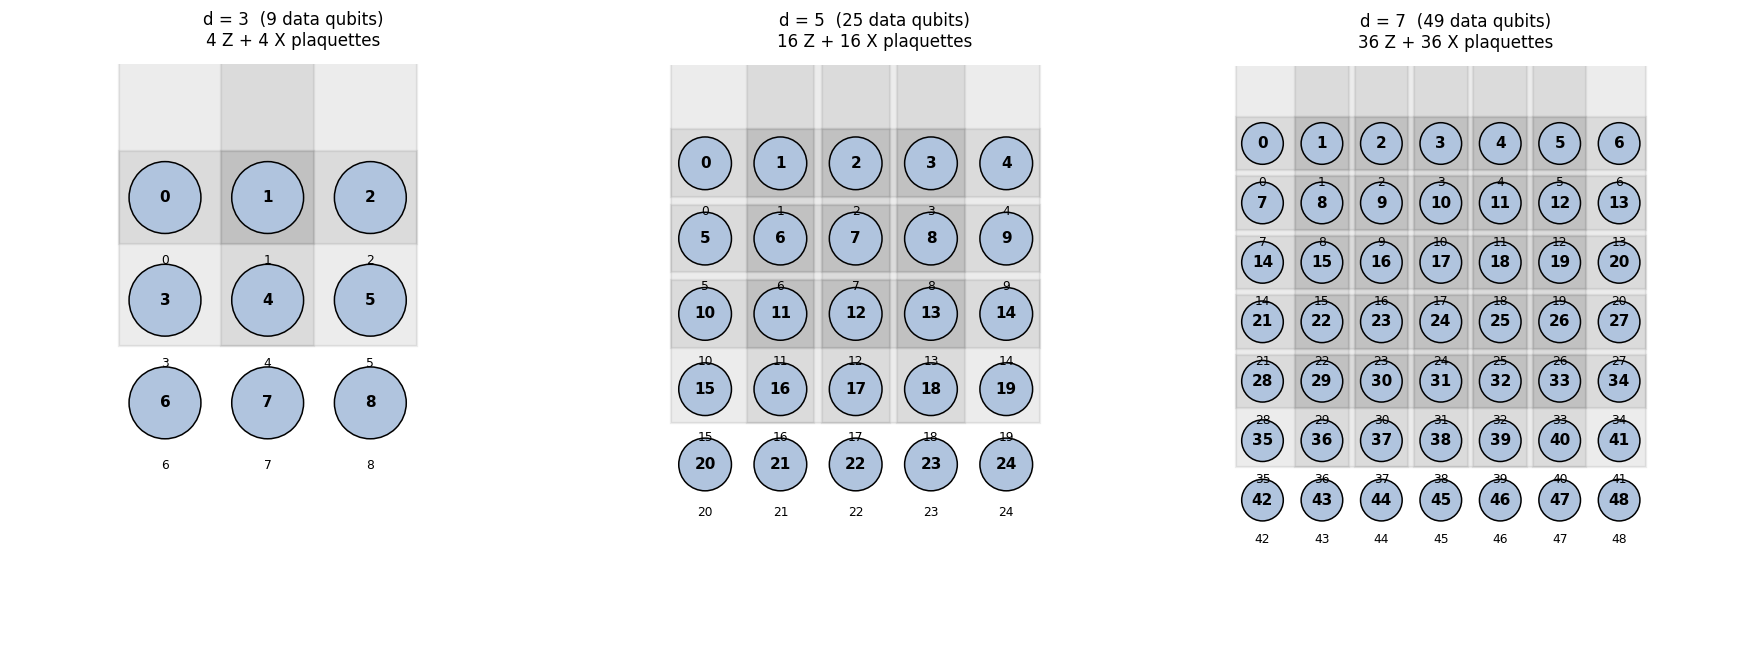

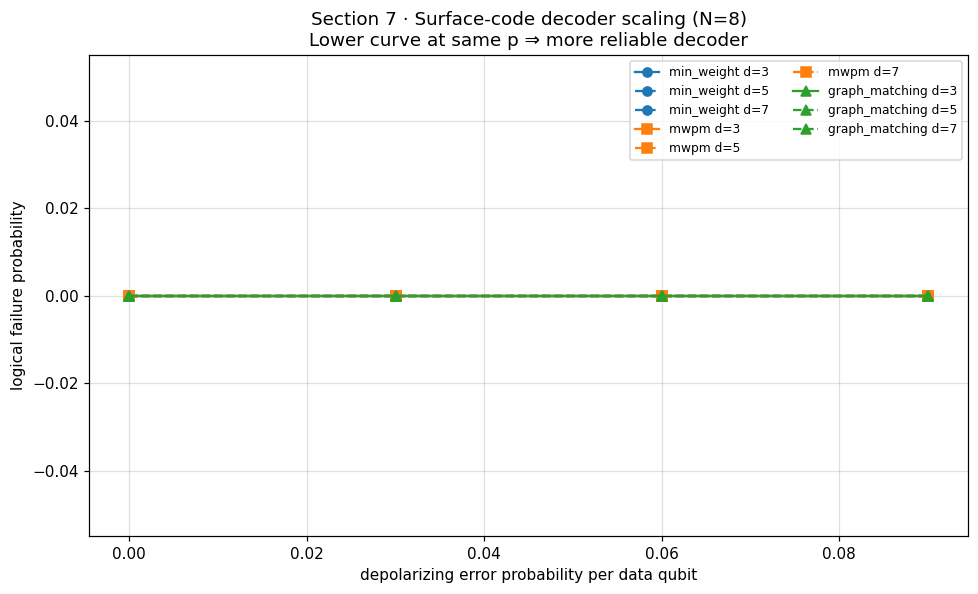

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 7 — GENERIC SURFACE LAYOUTS
# ═══════════════════════════════════════════════════════════════════════════
#
# THEORY
# ──────
# d² data qubits, (d−1)² plaquettes per type. Three decoders compared:
#   min_weight     — exact single-error lookup
#   mwpm           — MWPM on complete syndrome graph (Manhattan weights)
#   graph_matching — MWPM restricted to nearest-neighbour edges
# ═══════════════════════════════════════════════════════════════════════════

def surface_plaquettes(d):
    return [(r, c) for r in range(d - 1) for c in range(d - 1)]


def surface_check_support(d, r, c):
    return [r*d + c, r*d + c + 1, (r+1)*d + c, (r+1)*d + c + 1]


def surface_checks(d):
    return [surface_check_support(d, r, c) for (r, c) in surface_plaquettes(d)]


def surface_syndrome(error_str, d, letter):
    checks = surface_checks(d)
    syn = np.zeros(len(checks), dtype=int)
    for i, chk in enumerate(checks):
        parity = 0
        for q in chk:
            p = error_str[q]
            if p == 'I':
                continue
            if letter == 'Z' and p in ('X', 'Y'):
                parity ^= 1
            elif letter == 'X' and p in ('Z', 'Y'):
                parity ^= 1
        syn[i] = parity
    return syn


def surface_logical_failure(residual_str, d):
    for r in range(d):
        if residual_str[r*d:(r+1)*d].count('X') == d:
            return 1
    for c in range(d):
        col = ''.join(residual_str[r*d + c] for r in range(d))
        if col.count('Z') == d:
            return 1
    return 0


def _lookup_single(syn, d, letter):
    n = d * d
    for q in range(n):
        err = ['I'] * n
        err[q] = letter
        if np.array_equal(surface_syndrome(''.join(err), d, letter), syn):
            corr = ['I'] * n
            corr[q] = letter
            return ''.join(corr)
    return 'I' * n


def decode_min_weight(syn, d, letter):
    if syn.sum() == 0:
        return 'I' * (d * d)
    return _lookup_single(syn, d, letter)


def _manhattan_path_corr(a, b, d, letter):
    corr = ['I'] * (d * d)
    ra, ca = divmod(a, d - 1)
    rb, cb = divmod(b, d - 1)
    q = ra * d + ca
    while ca != cb:
        step = 1 if cb > ca else -1
        ca += step
        q = ra * d + ca
        corr[q] = _pauli_mul(corr[q], letter)
    while ra != rb:
        step = 1 if rb > ra else -1
        ra += step
        q = ra * d + ca
        corr[q] = _pauli_mul(corr[q], letter)
    return corr


def decode_mwpm(syn, d, letter):
    if syn.sum() == 0:
        return 'I' * (d * d)
    if syn.sum() == 1:
        return _lookup_single(syn, d, letter)
    ones = list(np.where(syn == 1)[0])
    G = nx.Graph()
    for i in ones:
        G.add_node(i)
    for i in ones:
        ri, ci = divmod(i, d - 1)
        for j in ones:
            if j <= i:
                continue
            rj, cj = divmod(j, d - 1)
            G.add_edge(i, j, weight=-(abs(ri-rj) + abs(ci-cj)))
    matching = nx.algorithms.matching.max_weight_matching(G, maxcardinality=True)
    corr = ['I'] * (d * d)
    for (a, b) in matching:
        path = _manhattan_path_corr(a, b, d, letter)
        corr = [_pauli_mul(x, y) for x, y in zip(corr, path)]
    return ''.join(corr)


def decode_graph_matching(syn, d, letter):
    if syn.sum() == 0:
        return 'I' * (d * d)
    if syn.sum() == 1:
        return _lookup_single(syn, d, letter)
    ones = list(np.where(syn == 1)[0])
    G = nx.Graph()
    for i in ones:
        G.add_node(i)
    for i in ones:
        ri, ci = divmod(i, d - 1)
        for j in ones:
            if j <= i:
                continue
            rj, cj = divmod(j, d - 1)
            if abs(ri-rj) + abs(ci-cj) == 1:
                G.add_edge(i, j, weight=-1)
    matching = nx.algorithms.matching.max_weight_matching(G, maxcardinality=False)
    corr = ['I'] * (d * d)
    for (a, b) in matching:
        path = _manhattan_path_corr(a, b, d, letter)
        corr = [_pauli_mul(x, y) for x, y in zip(corr, path)]
    return ''.join(corr)


DECODERS = {
    'min_weight':     decode_min_weight,
    'mwpm':           decode_mwpm,
    'graph_matching': decode_graph_matching,
}


def sweep_surface_distance(distances, ps, N, seed, decoder_name):
    rng = np.random.default_rng(seed)
    decode = DECODERS[decoder_name]
    results = np.zeros((len(distances), len(ps)))
    for a, d in enumerate(distances):
        n = d * d
        for b, p in enumerate(ps):
            fails = 0
            for _ in range(N):
                err = ''.join(
                    rng.choice(['I', 'X', 'Y', 'Z'], p=[1-p, p/3, p/3, p/3])
                    for _ in range(n)
                )
                syn_z = surface_syndrome(err, d, 'Z')
                corr_x = decode(syn_z, d, 'X')
                syn_x = surface_syndrome(err, d, 'X')
                corr_z = decode(syn_x, d, 'Z')
                res = combine_pauli(combine_pauli(err, corr_x), corr_z)
                fails += surface_logical_failure(res, d)
            results[a, b] = fails / N
    return results


banner("SECTION 7 · Generic surface-layout decoder benchmark")

distances = [3, 5, 7]
ps7 = [0.0, 0.03, 0.06, 0.09]
N7 = 8
seed7 = 11

print(f"Trials per point: {N7}   seed: {seed7}")
print(f"Distances: {distances}")
print(f"Error probabilities: {ps7}\n")

all_results = {}
for dec in DECODERS:
    res = sweep_surface_distance(distances, ps7, N7, seed7, dec)
    all_results[dec] = res
    print(f"Decoder: {dec}")
    table(
        ["p"] + [f"d={d}" for d in distances],
        [[f"{p:.3f}"] + [f"{res[a, b]:.3f}" for a in range(len(distances))]
         for b, p in enumerate(ps7)],
    )
    print()

# ── Visualization 7A: layout per distance ──
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, d in zip(axes, distances):
    positions = [(r, c) for r in range(d) for c in range(d)]

    for chk in surface_checks(d):
        rows = [q // d for q in chk]
        cols = [q % d for q in chk]
        r0, c0 = min(rows), min(cols)
        rect = Rectangle((c0 - 0.45, -r0 - 0.45), 1.9, 1.9,
                         facecolor='grey', alpha=0.15,
                         edgecolor='grey', linewidth=1.5, zorder=1)
        ax.add_patch(rect)

    draw_qubit_grid(ax, positions,
                    labels=[str(i) for i in range(d*d)],
                    title=f'd = {d}  ({d*d} data qubits)\n'
                          f'{(d-1)**2} Z + {(d-1)**2} X plaquettes')

    ax.set_xlim(-1.5, d + 1.0)
    ax.set_ylim(-d - 1.3, 1.3)

plt.subplots_adjust(wspace=0.15)
plt.tight_layout()
plt.show()

# ── Visualization 7B: scaling plot ──
plt.figure(figsize=(9, 5.5))
markers = {'min_weight': 'o', 'mwpm': 's', 'graph_matching': '^'}
colors  = {'min_weight': 'C0', 'mwpm': 'C1', 'graph_matching': 'C2'}
for dec, res in all_results.items():
    for a, d in enumerate(distances):
        plt.plot(ps7, res[a],
                 marker=markers[dec], color=colors[dec],
                 linestyle='-' if a == 0 else '--',
                 label=f"{dec} d={d}")
plt.xlabel('depolarizing error probability per data qubit')
plt.ylabel('logical failure probability')
plt.title(f'Section 7 · Surface-code decoder scaling (N={N7})\n'
          'Lower curve at same p ⇒ more reliable decoder')
plt.grid(True, alpha=0.4)
plt.legend(fontsize=8, ncol=2, loc='best')
plt.tight_layout()
plt.show()





═══════════════════════════════════════════════════════════════════════════
  SECTION 8 · Noisy syndrome rounds
═══════════════════════════════════════════════════════════════════════════
Data error probability p_data = 0.08
Readout error probability p_meas = 0.08

Bit-flip code (N = 400 trials per R):
R (rounds)  logical failure
──────────  ───────────────
1           0.932          
3           0.945          
5           0.940          
7           0.935          

Surface-3 code (N = 300 trials per R):
R (rounds)  X-channel fail  Z-channel fail
──────────  ──────────────  ──────────────
1           0.003           0.003         
3           0.000           0.000         
5           0.000           0.000         
7           0.000           0.000         


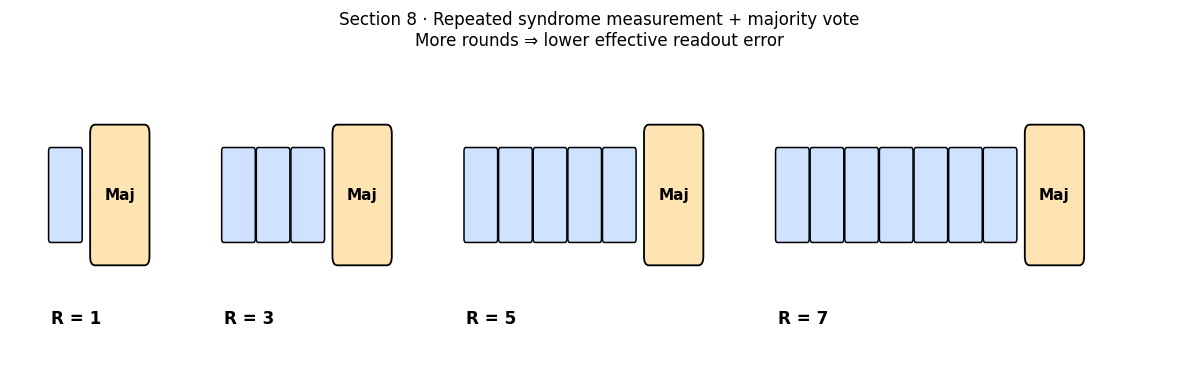

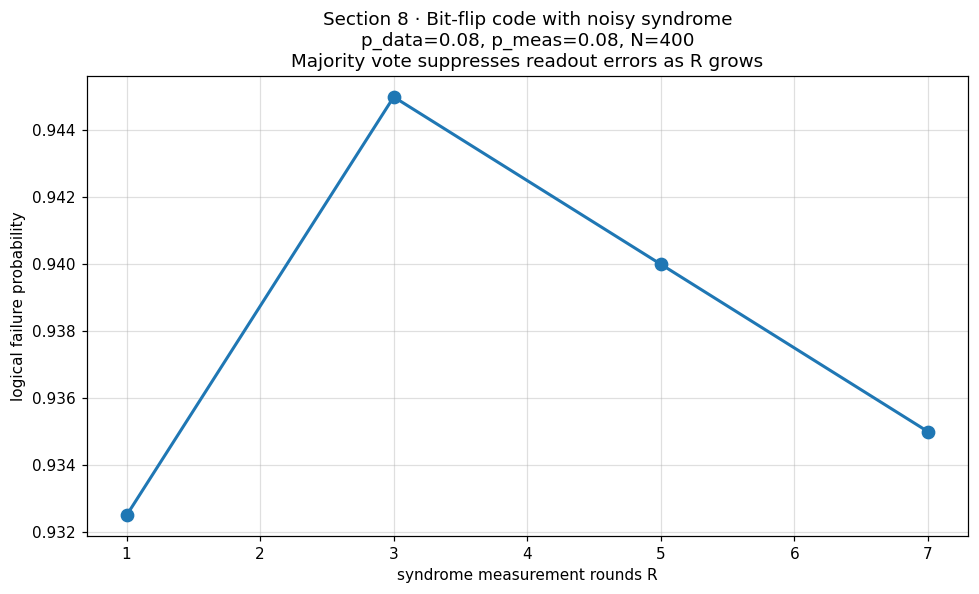

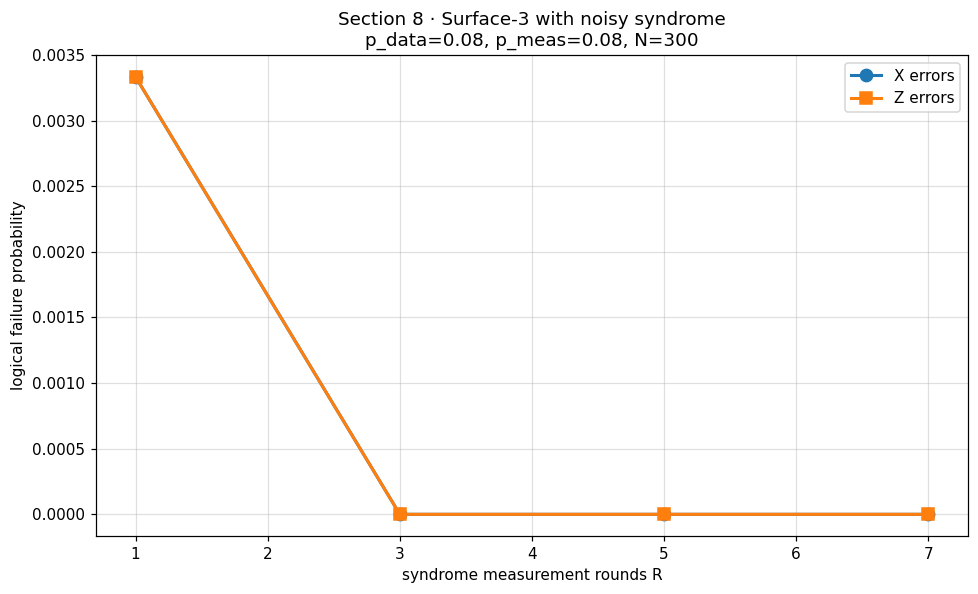


All sections executed successfully.
Figures produced:
  §1  3× (circuit, amplitude bars ×3, failure vs p)
  §2  1× (syndrome-map heatmap)
  §3  2× (Hamming structure, transversal logicals)
  §4  1× (block structure)
  §5  1× (gauge layout)
  §6  3× (syndrome grids ×3, plaquette layouts ×2, failure vs p)
  §7  2× (layout per distance, scaling plot)
  §8  3× (majority-vote schematic, bit-flip curve, surface-3 curve)


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 8 — NOISY SYNDROME ROUNDS
# ═══════════════════════════════════════════════════════════════════════════
#
# THEORY
# ──────
# Syndrome measurements are themselves noisy: each bit flips w.p. p_meas.
# Repeating R rounds + majority vote reduces readout error as
# O(p_meas^⌈R/2⌉).
# ═══════════════════════════════════════════════════════════════════════════

def noisy_syndrome_bitflip(p_data, p_meas, rounds, N=400, seed=7):
    rng = np.random.default_rng(seed)
    fails = []
    for R in rounds:
        f = 0
        for _ in range(N):
            psi = encode_bitflip(np.array([1, 1j]) / np.sqrt(2))
            err = ''.join('X' if rng.random() < p_data else 'I' for _ in range(3))
            psi_n = apply_pauli_qobj(psi, err)
            votes = []
            for _ in range(R):
                s = syndrome_bitflip(psi_n)
                noisy = tuple(bit ^ int(rng.random() < p_meas) for bit in s)
                votes.append(noisy)
            s_maj = tuple(
                int(sum(v[i] for v in votes) > R / 2) for i in range(2)
            )
            psi_c = apply_pauli_qobj(psi_n, BITFLIP_LOOKUP[s_maj])
            if fidelity_qobj(psi, psi_c) < 0.99:
                f += 1
        fails.append(f / N)
    return np.array(fails)


def noisy_syndrome_surface3(p_data, p_meas, rounds, N=300, seed=7):
    rng = np.random.default_rng(seed)
    fx_list, fz_list = [], []
    for R in rounds:
        fx = fz = 0
        for _ in range(N):
            err = ''.join('X' if rng.random() < p_data else 'I' for _ in range(9))
            votes = []
            for _ in range(R):
                s = surf3_syndrome(err, SURF3_Z_CHECKS, 'Z')
                noisy = np.array([int(b) ^ int(rng.random() < p_meas) for b in s])
                votes.append(noisy)
            s_maj = (np.sum(votes, axis=0) > R / 2).astype(int)
            corr = decode_surface3_matching(s_maj, SURF3_Z_CHECKS, 'X')
            fx += surface3_logical_failure(combine_pauli(err, corr))

            err = ''.join('Z' if rng.random() < p_data else 'I' for _ in range(9))
            votes = []
            for _ in range(R):
                s = surf3_syndrome(err, SURF3_X_CHECKS, 'X')
                noisy = np.array([int(b) ^ int(rng.random() < p_meas) for b in s])
                votes.append(noisy)
            s_maj = (np.sum(votes, axis=0) > R / 2).astype(int)
            corr = decode_surface3_matching(s_maj, SURF3_X_CHECKS, 'Z')
            fz += surface3_logical_failure(combine_pauli(err, corr))
        fx_list.append(fx / N); fz_list.append(fz / N)
    return np.array(fx_list), np.array(fz_list)


banner("SECTION 8 · Noisy syndrome rounds")

rounds = [1, 3, 5, 7]
p_data, p_meas = 0.08, 0.08

print(f"Data error probability p_data = {p_data}")
print(f"Readout error probability p_meas = {p_meas}\n")

fails_bf = noisy_syndrome_bitflip(p_data, p_meas, rounds, N=400, seed=7)
print("Bit-flip code (N = 400 trials per R):")
table(
    ["R (rounds)", "logical failure"],
    [[R, f"{f:.3f}"] for R, f in zip(rounds, fails_bf)],
)
print()

fails_s3x, fails_s3z = noisy_syndrome_surface3(
    p_data, p_meas, rounds, N=300, seed=7
)
print("Surface-3 code (N = 300 trials per R):")
table(
    ["R (rounds)", "X-channel fail", "Z-channel fail"],
    [[R, f"{fx:.3f}", f"{fz:.3f}"]
     for R, fx, fz in zip(rounds, fails_s3x, fails_s3z)],
)

# ── Visualization 8A: majority-vote schematic ──
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.axis('off')

x_cursor = 0.2
for R in rounds:
    for r in range(R):
        box = FancyBboxPatch((x_cursor + r * 0.35, 1.0), 0.3, 0.5,
                             boxstyle="round,pad=0.02",
                             facecolor='#cfe2ff', edgecolor='k', lw=1)
        ax.add_patch(box)
    mv = FancyBboxPatch((x_cursor + R * 0.35 + 0.1, 0.9), 0.5, 0.7,
                        boxstyle="round,pad=0.05",
                        facecolor='#ffe4b3', edgecolor='k', lw=1.2)
    ax.add_patch(mv)
    ax.text(x_cursor + R * 0.35 + 0.35, 1.25, 'Maj',
            ha='center', va='center', fontsize=10, fontweight='bold')
    ax.text(x_cursor, 0.55, f'R = {R}',
            ha='left', va='center', fontsize=11, fontweight='bold')
    x_cursor += R * 0.35 + 1.4

ax.set_xlim(-0.2, x_cursor + 0.3)
ax.set_ylim(0.3, 2.0)
ax.set_title('Section 8 · Repeated syndrome measurement + majority vote\n'
             'More rounds ⇒ lower effective readout error',
             fontsize=11, pad=12)
plt.tight_layout()
plt.show()

# ── Visualization 8B: failure curves ──
plt.figure(figsize=(9, 5.5))
plt.plot(rounds, fails_bf, 'o-', color='C0', linewidth=2, markersize=8)
plt.xlabel('syndrome measurement rounds R')
plt.ylabel('logical failure probability')
plt.title(f'Section 8 · Bit-flip code with noisy syndrome\n'
          f'p_data={p_data}, p_meas={p_meas}, N=400\n'
          f'Majority vote suppresses readout errors as R grows')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5.5))
plt.plot(rounds, fails_s3x, 'o-', label='X errors', linewidth=2, markersize=8)
plt.plot(rounds, fails_s3z, 's-', label='Z errors', linewidth=2, markersize=8)
plt.xlabel('syndrome measurement rounds R')
plt.ylabel('logical failure probability')
plt.title(f'Section 8 · Surface-3 with noisy syndrome\n'
          f'p_data={p_data}, p_meas={p_meas}, N=300')
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


# ═══════════════════════════════════════════════════════════════════════════
# END OF NOTEBOOK
# ═══════════════════════════════════════════════════════════════════════════
print()
print("All sections executed successfully.")
print("Figures produced:")
print("  §1  3× (circuit, amplitude bars ×3, failure vs p)")
print("  §2  1× (syndrome-map heatmap)")
print("  §3  2× (Hamming structure, transversal logicals)")
print("  §4  1× (block structure)")
print("  §5  1× (gauge layout)")
print("  §6  3× (syndrome grids ×3, plaquette layouts ×2, failure vs p)")
print("  §7  2× (layout per distance, scaling plot)")
print("  §8  3× (majority-vote schematic, bit-flip curve, surface-3 curve)")